# Google Stock Price Prediction using RNN

**Problem Statement:** Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

**Dataset:** Google Stock Price CSV from Kaggle  
> Dataset link: https://www.kaggle.com/datasets/henryshan/google-stock-price

**Model:** Long Short-Term Memory (LSTM) — a type of Recurrent Neural Network (RNN)


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load and Explore the Dataset

**Way 1:** Load from Kaggle CSV — place GOOG.csv in same folder.  

**Way 2:** Use yfinance package to fetch stock data directly (active).

In [3]:
# ── Way 1: Load from Kaggle CSV ────────
# df = pd.read_csv('GOOG.csv')

# ── Way 2: Use yfinance to fetch directly (active) ──────────────────────────────────
!pip install yfinance -q
import yfinance as yf
df = yf.download('GOOG', start='2004-08-19', end='2023-12-06', progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df.reset_index(inplace=True)

In [4]:
print("Shape:", df.shape)

Shape: (4858, 6)


In [5]:
# Show first 5 rows
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2004-08-19,2.478783,2.570680,2.370580,2.470383,897427216
1,2004-08-20,2.675672,2.694694,2.482735,2.495334,458857488
2,2004-08-23,2.702599,2.803390,2.693953,2.735949,366857939
3,2004-08-24,2.590691,2.756947,2.558575,2.748054,306396159
4,2004-08-25,2.618605,2.668014,2.566233,2.592913,184645512


In [6]:
# Check column names and data types
print(df.dtypes)

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [7]:
# Check Missing Values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [8]:
# Parse Date column and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')          # sort oldest to newest
df.set_index('Date', inplace=True)

In [9]:
print("Date range:", df.index.min(), "to", df.index.max())
df.head()

Date range: 2004-08-19 00:00:00 to 2023-12-05 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-08-19,2.478783,2.570680,2.370580,2.470383,897427216
2004-08-20,2.675672,2.694694,2.482735,2.495334,458857488
2004-08-23,2.702599,2.803390,2.693953,2.735949,366857939
2004-08-24,2.590691,2.756947,2.558575,2.748054,306396159
2004-08-25,2.618605,2.668014,2.566233,2.592913,184645512


## Step 3: Visualize the Closing Price

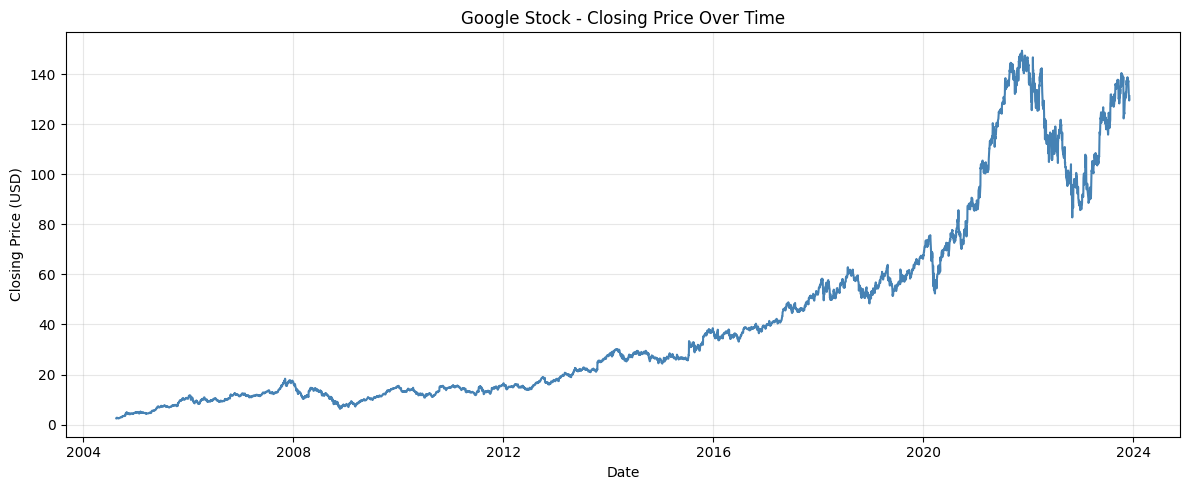

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], color='steelblue', linewidth=1.5)
plt.title('Google Stock - Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Preprocess the Data

### 4a. Use only the 'Close' price column
We predict future **Close** prices based on past Close prices.

In [11]:
# Extract the Close column
close_prices = df[['Close']].values   # shape: (N, 1)

In [12]:
print("Total data points:", len(close_prices))

Total data points: 4858


### 4b. Normalize the Data (MinMax Scaling)
LSTM works best when data is scaled between 0 and 1.

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [15]:
scaled_data = scaler.fit_transform(close_prices)

### 4c. Create Sequences for LSTM
LSTM uses a **sliding window** approach.  
We use the past `LOOK_BACK` days to predict the next day's price.

In [16]:
LOOK_BACK = 60   # use last 60 days to predict next day

In [17]:
X, y = [], []

In [18]:
for i in range(LOOK_BACK, len(scaled_data)):
    X.append(scaled_data[i - LOOK_BACK : i, 0])   # 60 days input
    y.append(scaled_data[i, 0])                    # next day output

In [19]:
X, y = np.array(X), np.array(y)

In [20]:
# Reshape X for LSTM: (samples, time_steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4798, 60, 1)
y shape: (4798,)


### 4d. Train-Test Split

> **Why `shuffle=False`?**  
> For time series data, the **order of data matters** (older data → newer data).  
> If we shuffle (default behavior), the model can accidentally see **future data** during training, which is called **data leakage** and gives falsely good results.  


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
# shuffle=False is IMPORTANT for time-series — preserves chronological order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

In [24]:
print("Training samples :", X_train.shape[0])
print("Testing  samples :", X_test.shape[0])

Training samples : 3838
Testing  samples : 960


## Step 5: Build the LSTM Model

We build a 2-layer LSTM with Dropout to avoid overfitting.

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [26]:
model = Sequential([
    # First LSTM layer
    LSTM(units=50, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),

    # Second LSTM layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    # Output layer — predict 1 value (next day's price)
    Dense(units=1)
])

In [27]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

In [29]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 8.3894e-04 - val_loss: 1.4592e-04
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 2.4318e-04 - val_loss: 7.6297e-04
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 2.0091e-04 - val_loss: 1.4667e-04
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.8534e-04 - val_loss: 2.9557e-04
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.8382e-04 - val_loss: 1.7164e-04
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.5361e-04 - val_loss: 1.3143e-04
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.4065e-04 - val_loss: 2.2601e-04
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.3523e-04 - val_loss: 1.5793e-04
Epoch 9/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.4508e-04 - val_loss: 1.1629e-04
Epoch 10/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.2831e-04 - val_loss: 1.3806e-04
Epoch 11/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/

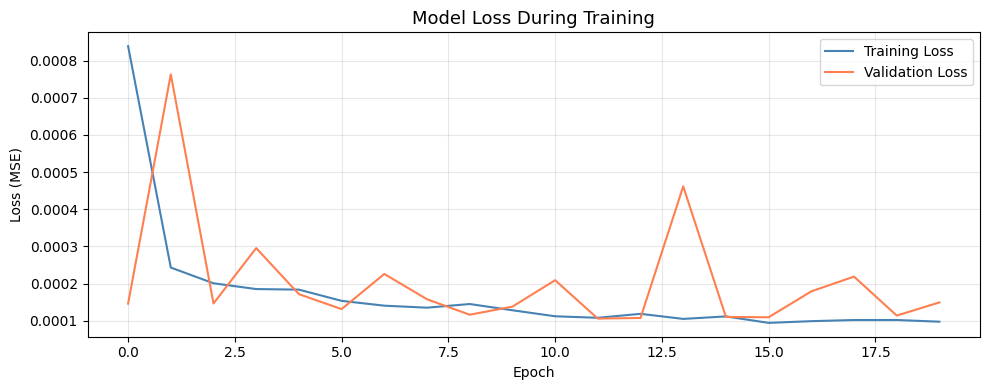

In [30]:
# Plot training vs validation loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral')
plt.title('Model Loss During Training', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Make Predictions

In [31]:
# Predict on test data
y_pred_scaled = model.predict(X_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [32]:
# Inverse transform — convert back to original price scale
y_pred   = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [33]:
print("Predictions shape:", y_pred.shape)

Predictions shape: (960, 1)


## Step 8: Evaluate and Visualize Results

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)

In [36]:
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error    (MAE) : {mae:.2f}")

Root Mean Squared Error (RMSE): 3.81
Mean Absolute Error    (MAE) : 2.92


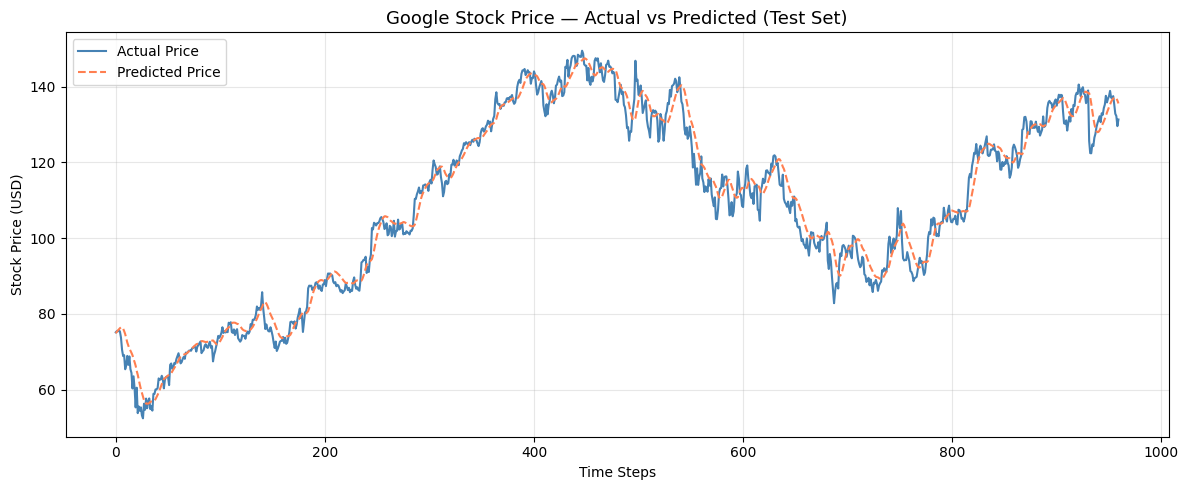

In [37]:
# Plot Actual vs Predicted prices
plt.figure(figsize=(12, 5))
plt.plot(y_actual, label='Actual Price',    color='steelblue', linewidth=1.5)
plt.plot(y_pred,   label='Predicted Price', color='coral',     linewidth=1.5, linestyle='--')
plt.title('Google Stock Price — Actual vs Predicted (Test Set)', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()